In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

os.makedirs('../figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
with open('../results/results.json') as f:
    store = json.load(f)
with open('../results/results_bj.json') as f:
    bj_store = json.load(f)

_DS_ORDER = ['whas500', 'gbsg', 'support', 'metabric', 'flchain']
datasets  = [k for k in _DS_ORDER if k in store]
print('Datasets available:', datasets)

Datasets available: ['whas500', 'gbsg', 'support', 'metabric', 'flchain']


In [3]:
records = []
for ds, methods in store.items():
    if ds == 'last_updated':
        continue
    for method, splits in methods.items():
        for s in splits:
            records.append({'dataset': ds, 'method': method,
                            'C-index': s['ci'], 'IBS': s['ibs']})

for raw_key, ds_data in bj_store.items():
    if raw_key == 'last_updated':
        continue
    backend = raw_key.split('_seed')[0]   # 'tabpfn_seed0' → 'tabpfn'
    for ds, splits in ds_data.items():
        for split_iters in splits:
            last = split_iters[-1]
            records.append({'dataset': ds, 'method': f'fsa_bs_{backend}',
                            'C-index': last['CI'], 'IBS': last['IBS']})

df = pd.DataFrame(records)
print(df.groupby(['dataset', 'method'])[['C-index', 'IBS']].mean().round(3))

                            C-index    IBS
dataset  method                           
flchain  bin_fsa_tabicl       0.717  0.095
         bin_fsa_tabpfn       0.715  0.095
         cox                  0.724  0.100
         fsa_bs_tabicl        0.777  0.121
         fsa_bs_tabpfn        0.791  0.136
         fsa_tabicl           0.661  0.238
         fsa_tabpfn           0.665  0.234
         lognormal            0.797  0.101
         pseudo_fsa_tabicl    0.568  0.115
         pseudo_fsa_tabpfn    0.714  0.106
         rsf                  0.725  0.100
         weibull              0.797  0.099
gbsg     bin_fsa_tabicl       0.675  0.189
         bin_fsa_tabpfn       0.673  0.190
         cox                  0.661  0.190
         fsa_bs_tabicl        0.687  0.217
         fsa_bs_tabpfn        0.680  0.220
         fsa_tabicl           0.662  0.256
         fsa_tabpfn           0.656  0.272
         lognormal            0.669  0.188
         pseudo_fsa_tabicl    0.504  0.227
         ps

In [4]:
import matplotlib.patches as mpatches

DATASET_LABELS = {
    'whas500':  'WHAS500',
    'gbsg':     'GBSG',
    'support':  'SUPPORT',
    'metabric': 'METABRIC',
    'flchain':  'FLCHAIN',
}

METHOD_ORDER = [
    'fsa_tabpfn',        'fsa_tabicl',
    'pseudo_fsa_tabpfn', 'pseudo_fsa_tabicl',
    'fsa_bs_tabpfn',     'fsa_bs_tabicl',
    'bin_fsa_tabpfn',    'bin_fsa_tabicl',
    'cox', 'weibull', 'lognormal', 'rsf',
]

METHOD_LABELS = {
    'fsa_tabpfn':        'FSA (PFN)',       'fsa_tabicl':        'FSA (ICL)',
    'pseudo_fsa_tabpfn': 'FSA-PO (PFN)',    'pseudo_fsa_tabicl': 'FSA-PO (ICL)',
    'fsa_bs_tabpfn':     'FSA-BJ (PFN)',    'fsa_bs_tabicl':     'FSA-BJ (ICL)',
    'bin_fsa_tabpfn':    'BinFSA (PFN)',    'bin_fsa_tabicl':    'BinFSA (ICL)',
    'cox':       'Cox PH',
    'weibull':   'Weibull AFT',
    'lognormal': 'LogNorm AFT',
    'rsf':       'RSF',
}

# Color: backend (tabpfn=purple, tabicl=coral); bin_fsa=green (external method)
# Hatch: mechanism
_C_TABPFN   = '#9b8ec4'
_C_TABICL   = '#e8885a'
_C_BIN      = '#6aab7e'
_C_BIN_ALT  = '#a8cdb4'
_C_BASELINE = '#6baed6'

METHOD_COLORS = {
    'fsa_tabpfn':        _C_TABPFN,    'fsa_tabicl':        _C_TABICL,
    'pseudo_fsa_tabpfn': _C_TABPFN,    'pseudo_fsa_tabicl': _C_TABICL,
    'fsa_bs_tabpfn':     _C_TABPFN,    'fsa_bs_tabicl':     _C_TABICL,
    'bin_fsa_tabpfn':    _C_BIN,       'bin_fsa_tabicl':    _C_BIN_ALT,
    'cox':       _C_BASELINE, 'weibull':   _C_BASELINE,
    'lognormal': _C_BASELINE, 'rsf':       _C_BASELINE,
}

METHOD_HATCHES = {
    'fsa_tabpfn':        '',    'fsa_tabicl':        '',
    'pseudo_fsa_tabpfn': '//',  'pseudo_fsa_tabicl': '//',
    'fsa_bs_tabpfn':     'xx',  'fsa_bs_tabicl':     'xx',
    'bin_fsa_tabpfn':    '||',  'bin_fsa_tabicl':    '||',
    'cox':       '',    'weibull':   '//',
    'lognormal': '\\\\', 'rsf':      '..',
}

# Separators after each mechanism pair (groups tabpfn+tabicl visually)
_SEP_GROUPS = [
    {'fsa_tabpfn',        'fsa_tabicl'},
    {'pseudo_fsa_tabpfn', 'pseudo_fsa_tabicl'},
    {'fsa_bs_tabpfn',     'fsa_bs_tabicl'},
    {'bin_fsa_tabpfn',    'bin_fsa_tabicl'},
]

present = [m for m in METHOD_ORDER if m in df['method'].unique()]

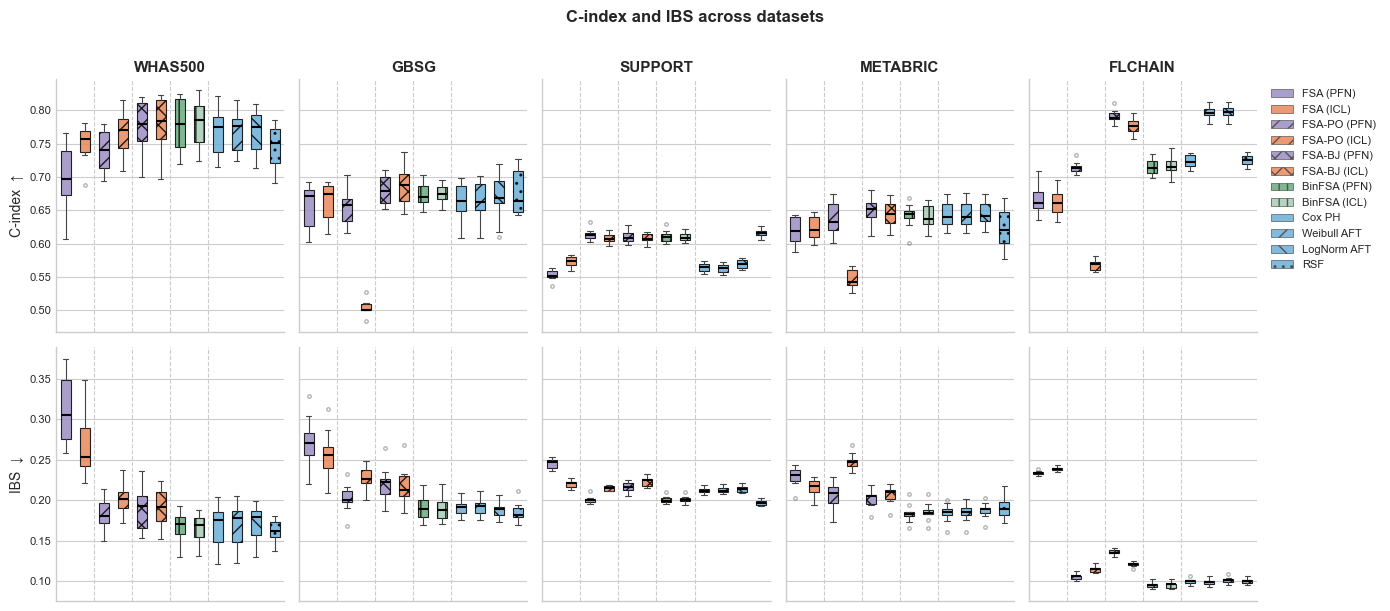

In [5]:
n_ds = len(datasets)
fig, axes = plt.subplots(2, n_ds, figsize=(2.8 * n_ds, 6), sharey='row')
if n_ds == 1:
    axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]
    for row, (metric, better) in enumerate([('C-index', '↑'), ('IBS', '↓')]):
        ax = axes[row, col]

        data = [sub[sub['method'] == m][metric].dropna().values for m in present]
        bp   = ax.boxplot(
            data, patch_artist=True, widths=0.55,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=0.8, color='#444444'),
            capprops=dict(linewidth=0.8, color='#444444'),
            flierprops=dict(marker='o', markersize=2.5, alpha=0.4,
                            linestyle='none', markeredgecolor='#444444'),
        )
        for patch, m in zip(bp['boxes'], present):
            patch.set_facecolor(METHOD_COLORS[m])
            patch.set_hatch(METHOD_HATCHES[m])
            patch.set_linewidth(0.8)
            patch.set_alpha(0.85)

        if row == 0:
            ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11,
                         fontweight='bold', pad=5)
        ax.set_xticks([])
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', labelsize=8)
        ax.set_ylabel(f'{metric}  {better}' if col == 0 else '', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

        # Separator after the last present method from each group
        for group in _SEP_GROUPS:
            indices = [present.index(m) for m in group if m in present]
            if indices:
                ax.axvline(max(indices) + 1.5, color='#cccccc',
                           linewidth=0.8, linestyle='--')

legend_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS[m], hatch=METHOD_HATCHES[m],
                   edgecolor='#444444', linewidth=0.5, label=METHOD_LABELS[m],
                   alpha=0.85)
    for m in present
]
axes[0, -1].legend(handles=legend_handles, fontsize=8, frameon=False,
                   loc='upper left', bbox_to_anchor=(1.02, 1))

fig.suptitle('C-index and IBS across datasets', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/results_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/results_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
rows = []
for ds in datasets:
    for method in present:
        sub = df[(df['dataset'] == ds) & (df['method'] == method)]
        if sub.empty:
            continue
        rows.append({
            'Dataset': ds, 'Method': METHOD_LABELS[method],
            'C-index': f"{sub['C-index'].mean():.3f} ± {sub['C-index'].std():.3f}",
            'IBS':     f"{sub['IBS'].mean():.3f} ± {sub['IBS'].std():.3f}",
        })

table = pd.DataFrame(rows).set_index(['Dataset', 'Method'])
display(table)

C-index            IBS
Dataset  Method                                    
whas500  FSA (PFN)     0.699 ± 0.048  0.311 ± 0.043
         FSA (ICL)     0.750 ± 0.027  0.267 ± 0.042
         FSA-PO (PFN)  0.740 ± 0.031  0.182 ± 0.020
         FSA-PO (ICL)  0.767 ± 0.033  0.202 ± 0.018
         FSA-BJ (PFN)  0.776 ± 0.039  0.191 ± 0.029
         FSA-BJ (ICL)  0.780 ± 0.040  0.191 ± 0.026
         BinFSA (PFN)  0.779 ± 0.040  0.166 ± 0.020
         BinFSA (ICL)  0.779 ± 0.035  0.165 ± 0.019
         Cox PH        0.768 ± 0.037  0.168 ± 0.026
         Weibull AFT   0.769 ± 0.032  0.169 ± 0.026
         LogNorm AFT   0.767 ± 0.032  0.171 ± 0.022
         RSF           0.745 ± 0.032  0.162 ± 0.014
gbsg     FSA (PFN)     0.656 ± 0.033  0.272 ± 0.030
         FSA (ICL)     0.662 ± 0.030  0.256 ± 0.029
         FSA-PO (PFN)  0.654 ± 0.025  0.202 ± 0.017
         FSA-PO (ICL)  0.504 ± 0.011  0.227 ± 0.014
         FSA-BJ (PFN)  0.680 ± 0.021  0.220 ± 0.021
         FSA-BJ (ICL)  0.687 ± 0.029  0.217 ± 0.023
         BinFSA (PFN)  0.673 ± 0.018  0.190 ± 0.015
         BinFSA (ICL)  0.675 ± 0.015  0.189 ± 0.015
         Cox PH        0.661 ± 0.031  0.190 ± 0.009
         Weibull AFT   0.662 ± 0.032  0.191 ± 0.010
         LogNorm AFT   0.669 ± 0.035  0.188 ± 0.009
         RSF           0.677 ± 0.034  0.185 ± 0.012
support  FSA (PFN)     0.553 ± 0.008  0.245 ± 0.006
         FSA (ICL)     0.573 ± 0.008  0.220 ± 0.004
         FSA-PO (PFN)  0.614 ± 0.008  0.201 ± 0.005
         FSA-PO (ICL)  0.608 ± 0.007  0.215 ± 0.003
         FSA-BJ (PFN)  0.610 ± 0.009  0.216 ± 0.006
         FSA-BJ (ICL)  0.608 ± 0.008  0.223 ± 0.006
         BinFSA (PFN)  0.611 ± 0.009  0.201 ± 0.004
         BinFSA (ICL)  0.610 ± 0.007  0.201 ± 0.004
         Cox PH        0.564 ± 0.007  0.212 ± 0.004
         Weibull AFT   0.563 ± 0.007  0.213 ± 0.004
         LogNorm AFT   0.570 ± 0.007  0.214 ± 0.004
         RSF           0.616 ± 0.006  0.197 ± 0.003
metabric FSA (PFN)     0.619 ± 0.021  0.229 ± 0.012
         FSA (ICL)     0.624 ± 0.018  0.216 ± 0.010
         FSA-PO (PFN)  0.637 ± 0.025  0.206 ± 0.016
         FSA-PO (ICL)  0.547 ± 0.014  0.248 ± 0.010
         FSA-BJ (PFN)  0.651 ± 0.020  0.202 ± 0.011
         FSA-BJ (ICL)  0.645 ± 0.019  0.207 ± 0.011
         BinFSA (PFN)  0.642 ± 0.018  0.184 ± 0.011
         BinFSA (ICL)  0.642 ± 0.018  0.185 ± 0.011
         Cox PH        0.643 ± 0.021  0.185 ± 0.011
         Weibull AFT   0.643 ± 0.021  0.185 ± 0.011
         LogNorm AFT   0.646 ± 0.018  0.187 ± 0.010
         RSF           0.624 ± 0.030  0.190 ± 0.014
flchain  FSA (PFN)     0.665 ± 0.022  0.234 ± 0.002
         FSA (ICL)     0.661 ± 0.019  0.238 ± 0.003
         FSA-PO (PFN)  0.714 ± 0.008  0.106 ± 0.004
         FSA-PO (ICL)  0.568 ± 0.008  0.115 ± 0.004
         FSA-BJ (PFN)  0.791 ± 0.009  0.136 ± 0.003
         FSA-BJ (ICL)  0.777 ± 0.012  0.121 ± 0.003
         BinFSA (PFN)  0.715 ± 0.011  0.095 ± 0.003
         BinFSA (ICL)  0.717 ± 0.014  0.095 ± 0.004
         Cox PH        0.724 ± 0.010  0.100 ± 0.003
         Weibull AFT   0.797 ± 0.009  0.099 ± 0.004
         LogNorm AFT   0.797 ± 0.009  0.101 ± 0.004
         RSF           0.725 ± 0.008  0.100 ± 0.004

In [10]:
bj_records = []
for raw_key, ds_data in bj_store.items():
    if raw_key == 'last_updated':
        continue
    backend = raw_key.split('_seed')[0]   # 'tabpfn_seed0' → 'tabpfn'
    for ds, splits in ds_data.items():
        for split_idx, iters in enumerate(splits):
            for row in iters:
                bj_records.append({
                    'dataset': ds, 'backend': backend, 'split': split_idx,
                    'Iter': row['Iter'], 'CI': row['CI'],
                    'IBS': row['IBS'], 'Sigma': row['Sigma'],
                })

gdf = pd.DataFrame(bj_records)
print('Datasets:', gdf['dataset'].unique())
print('Backends:', gdf['backend'].unique())
print(gdf.groupby(['backend', 'dataset', 'Iter'])[['CI', 'IBS', 'Sigma']].mean().round(3))

Datasets: ['whas500' 'gbsg' 'support' 'metabric' 'flchain']
Backends: ['tabpfn' 'tabicl']
                         CI    IBS  Sigma
backend dataset Iter                     
tabicl  flchain 1     0.619  0.108  4.614
                2     0.711  0.105  3.478
                3     0.719  0.106  2.976
                4     0.740  0.108  2.599
                5     0.752  0.110  2.331
...                     ...    ...    ...
tabpfn  whas500 6     0.774  0.188  2.035
                7     0.774  0.186  1.931
                8     0.778  0.189  1.878
                9     0.778  0.188  1.852
                10    0.776  0.191  1.772

[100 rows x 3 columns]


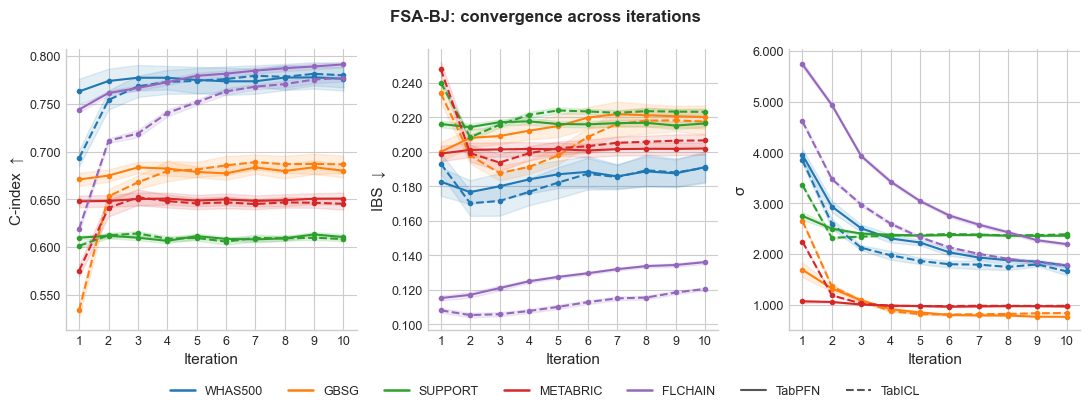

In [ ]:
import matplotlib.lines as mlines

BACKEND_STYLE = {'tabpfn': '-', 'tabicl': '--'}
bj_datasets   = [d for d in _DS_ORDER if d in gdf['dataset'].unique()]
ds_palette    = sns.color_palette("tab10", n_colors=len(bj_datasets))
ds_color      = dict(zip(bj_datasets, ds_palette))

metrics_to_plot = [('CI', 'C-index  ↑'), ('IBS', 'IBS  ↓'), ('Sigma', 'σ')]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

for ax, (col, ylabel) in zip(axes, metrics_to_plot):
    for ds in bj_datasets:
        for backend, ls in BACKEND_STYLE.items():
            sub = gdf[(gdf['dataset'] == ds) & (gdf['backend'] == backend)]
            if sub.empty:
                continue
            iters = sorted(sub['Iter'].unique())
            means = np.array([sub[sub['Iter'] == it][col].mean() for it in iters])
            ses   = np.array([sub[sub['Iter'] == it][col].std() /
                              np.sqrt(sub[sub['Iter'] == it][col].count()) for it in iters])
            ax.plot(iters, means, marker='o', markersize=3, linewidth=1.5,
                    color=ds_color[ds], linestyle=ls)
            ax.fill_between(iters, means - ses, means + ses, alpha=0.12, color=ds_color[ds])

    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(iters)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# ── Legend: one colored entry per dataset + linestyle reference ────────────────
ds_handles = [
    mlines.Line2D([], [], color=ds_color[ds], linewidth=1.8,
                  label=DATASET_LABELS.get(ds, ds))
    for ds in bj_datasets
]
style_handles = [
    mlines.Line2D([], [], color='#555555', linewidth=1.5, linestyle='-',  label='TabPFN'),
    mlines.Line2D([], [], color='#555555', linewidth=1.5, linestyle='--', label='TabICL'),
]
fig.legend(handles=ds_handles + style_handles,
           loc='lower center', ncol=len(bj_datasets) + 2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.07))

fig.suptitle('TabSA-BJ: convergence across iterations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/bj_convergence.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/bj_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'mlines' is not defined

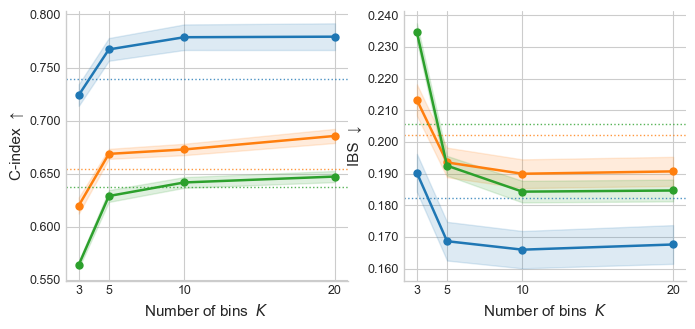

In [9]:
# ── Ablation: BinFSA performance vs number of bins K ─────────────────────────
with open('../results/results_ablation.json') as f:
    abl = json.load(f)

abl_datasets = [d for d in _DS_ORDER if d in abl['datasets']]
k_values     = abl['k_values']

# Reference: FSA-PO (TabPFN) per dataset from main results
ref_ci  = {ds: np.mean([x['ci']  for x in store[ds]['pseudo_fsa_tabpfn']]) for ds in abl_datasets}
ref_ibs = {ds: np.mean([x['ibs'] for x in store[ds]['pseudo_fsa_tabpfn']]) for ds in abl_datasets}

abl_palette = sns.color_palette("tab10", n_colors=len(abl_datasets))
abl_color   = dict(zip(abl_datasets, abl_palette))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, (metric_key, metric_label, better, ref_dict) in zip(axes, [
    ('ci',  'C-index', '↑', ref_ci),
    ('ibs', 'IBS',     '↓', ref_ibs),
]):
    for ds in abl_datasets:
        means = np.array([np.mean([x[metric_key] for x in abl['datasets'][ds][str(k)]]) for k in k_values])
        stds  = np.array([np.std( [x[metric_key] for x in abl['datasets'][ds][str(k)]]) for k in k_values])
        ses   = stds / np.sqrt(len(abl['datasets'][ds][str(k_values[0])]))
        color = abl_color[ds]

        ax.plot(k_values, means, marker='o', markersize=5, linewidth=1.8,
                color=color, label=DATASET_LABELS.get(ds, ds))
        ax.fill_between(k_values, means - ses, means + ses, alpha=0.15, color=color)

        # FSA-PO reference as horizontal dashed line (same color)
        ax.axhline(ref_dict[ds], color=color, linewidth=1.0,
                   linestyle=':', alpha=0.8)

    ax.set_xlabel('Number of bins  $K$', fontsize=11)
    ax.set_ylabel(f'{metric_label}  {better}', fontsize=11)
    ax.set_xticks(k_values)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# ── Legend ─────────────────────────────────────────────────────────────────────
ds_handles = [
    mlines.Line2D([], [], color=abl_color[ds], linewidth=1.8,
                  label=DATASET_LABELS.get(ds, ds))
    for ds in abl_datasets
]
ref_handle = mlines.Line2D([], [], color='#555555', linewidth=1.0,
                            linestyle=':', label='FSA-PO reference')
fig.legend(handles=ds_handles + [ref_handle],
           loc='lower center', ncol=len(abl_datasets) + 1,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig.suptitle('BinFSA: effect of number of bins $K$', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/ablation_bins.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/ablation_bins.png', dpi=300, bbox_inches='tight')
plt.show()